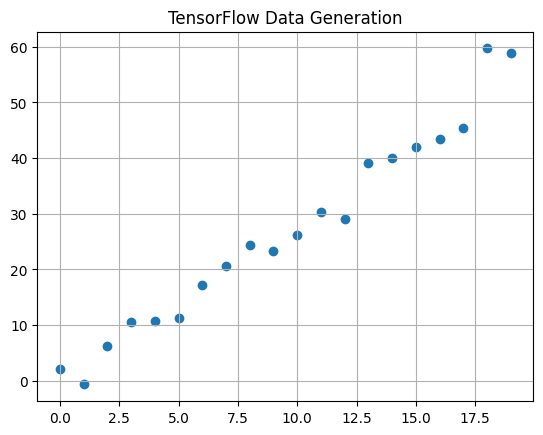

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. 0부터 19까지의 정수를 생성한 후, 실수형(float32)으로 변환합니다.
time = tf.cast(tf.range(0, 20), tf.float32)

# 2. tf.random.normal()을 사용하여 표준정규분포를 따르는 난수(노이즈)를 생성합니다.
# len(time) 대신 time.shape[0] 또는 tf.shape(time)을 사용하는 것이 텐서플로우 스타일입니다.
noise = tf.random.normal(shape=[time.shape[0]])

# 3. 선형 관계식에 노이즈를 더해 가격 데이터를 생성합니다.
price = 3 * time - 2 + noise * 3

# 4. 맷플롯립으로 시각화 (텐서 데이터는 자동으로 넘파이처럼 호환되어 그려집니다)
plt.scatter(time, price)
plt.grid(True)
plt.title("TensorFlow Data Generation")
plt.show()


파이토치(PyTorch) 코드를 텐서플로우(TensorFlow)로 바꾸려면 torch 모듈의 함수들을 대응하는 tf 함수로 매칭해 주면 됩니다.
가장 핵심이 되는 변환 포인트는 두 가지입니다.

* torch.arange() ➡️ tf.range()
* torch.randn() ➡️ tf.random.normal()

------------------------------
## 🛠️ 텐서플로우 버전 변환 코드
구글 코랩이나 주피터 노트북에서 바로 실행해 보실 수 있는 코드입니다.

import tensorflow as tfimport matplotlib.pyplot as plt
# 1. 0부터 19까지의 정수를 생성한 후, 실수형(float32)으로 변환합니다.time = tf.cast(tf.range(0, 20), tf.float32)
# 2. tf.random.normal()을 사용하여 표준정규분포를 따르는 난수(노이즈)를 생성합니다.# len(time) 대신 time.shape[0] 또는 tf.shape(time)을 사용하는 것이 텐서플로우 스타일입니다.noise = tf.random.normal(shape=[time.shape[0]])
# 3. 선형 관계식에 노이즈를 더해 가격 데이터를 생성합니다.price = 3 * time - 2 + noise * 3
# 4. 맷플롯립으로 시각화 (텐서 데이터는 자동으로 넘파이처럼 호환되어 그려집니다)
plt.scatter(time, price)
plt.grid(True)
plt.title("TensorFlow Data Generation")
plt.show()

## 💡 주요 변경점 톺아보기

   1. .float() ➡️ tf.cast(..., tf.float32)
   * 파이토치는 텐서 뒤에 .float()를 붙여 간단히 타입을 바꿀 수 있지만, 텐서플로우는 tf.cast() 함수로 감싸서 형변환을 해주는 것이 정석입니다.
   2. torch.randn(len(time)) ➡️ tf.random.normal(shape=[20])
   * 파이토치의 randn은 개수(차원 크기)를 바로 받지만, 텐서플로우의 random.normal은 구조를 의미하는 shape 배열을 인자로 받습니다.
   
------------------------------
이제 데이터 준비가 끝났으니, 이 데이터를 가지고 아까 작성하셨던 자동 미분(tf.GradientTape)과 optimizer를 활용해 기울기 3과 편향 -2를 예측하는 선형 회귀 학습 코드를 이어서 작성해 볼까요? 아니면 데이터 생성 부분에서 다른 궁금한 점이 있으신가요?
다음 단계로 어떤 작업을 원하시는지 말씀해 주세요:

* 생성된 time과 price 데이터를 학습시킬 선형 회귀 모델 구현하기
* 텐서플로우의 난수 생성(Random Seed) 설정 방법 알아보기




epoch :    0 | w의 값 : 2.5405 | b의 값 : 0.8840 | cost : 181.441406
epoch :    1 | w의 값 : 2.8945 | b의 값 : 0.9079 | cost : 19.014643
epoch :    2 | w의 값 : 2.8090 | b의 값 : 0.8979 | cost : 9.474634
epoch :    3 | w의 값 : 2.8300 | b의 값 : 0.8961 | cost : 8.912257
epoch :    4 | w의 값 : 2.8253 | b의 값 : 0.8924 | cost : 8.877065
epoch :    5 | w의 값 : 2.8267 | b의 값 : 0.8891 | cost : 8.872843
epoch :    6 | w의 값 : 2.8267 | b의 값 : 0.8857 | cost : 8.870450
epoch :    7 | w의 값 : 2.8270 | b의 값 : 0.8824 | cost : 8.868175
epoch :    8 | w의 값 : 2.8273 | b의 값 : 0.8790 | cost : 8.865920
epoch :    9 | w의 값 : 2.8275 | b의 값 : 0.8757 | cost : 8.863676
epoch :   10 | w의 값 : 2.8278 | b의 값 : 0.8724 | cost : 8.861444
epoch :   11 | w의 값 : 2.8280 | b의 값 : 0.8690 | cost : 8.859225
epoch :   12 | w의 값 : 2.8283 | b의 값 : 0.8657 | cost : 8.857018
epoch :   13 | w의 값 : 2.8286 | b의 값 : 0.8624 | cost : 8.854822
epoch :   14 | w의 값 : 2.8288 | b의 값 : 0.8592 | cost : 8.852640
epoch :   15 | w의 값 : 2.8291 | b의 값 : 0.8559 | cost 

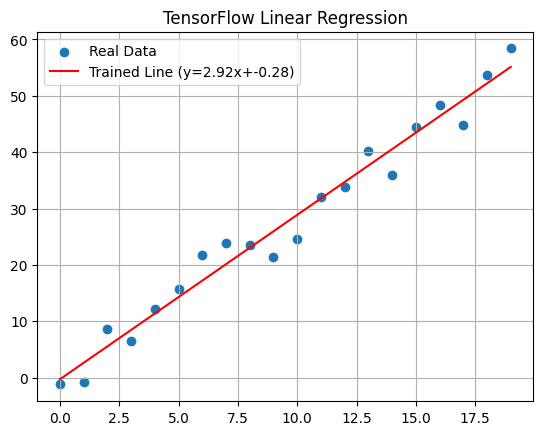

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 1. 난수 기반 데이터 생성 (제공해주신 코드 활용)
# ==========================================
# time을 x로, price를 y로 사용합니다.
x = tf.cast(tf.range(0, 20), tf.float32)

# 난수 생성이 매번 다르면 결과가 바뀌므로 원하시면 seed를 줄 수 있습니다.
noise = tf.random.normal(shape=[x.shape[0]])
y = 3 * x - 2 + noise * 3

# ==========================================
# 2. 선형 회귀 모델 선언 및 최적화 설정
# ==========================================
# 초기값은 랜덤하게 학습을 시작하도록 설정했습니다.
w = tf.Variable(4.0)
b = tf.Variable(1.0)

@tf.function
def hypothesis(x):
  return w * x + b

@tf.function
def mse_loss(y_pred, y):
  return tf.reduce_mean(tf.square(y_pred - y))

# 💡 중요: x값이 최대 19까지 커졌기 때문에, 기존의 학습률 0.01을 쓰면
# 기울기가 너무 크게 튀어서 발산(오류)할 수 있습니다. 0.005로 안정화합니다.
optimizer = tf.optimizers.SGD(learning_rate=0.005)

# ==========================================
# 3. 경사하강법 학습 진행
# ==========================================
# 데이터가 늘어났으므로 충분한 학습을 위해 에포크를 1001회로 늘립니다.
for i in range(1001):
  with tf.GradientTape() as tape:
    y_pred = hypothesis(x)
    cost = mse_loss(y_pred, y)

  # 손실 함수에 대한 파라미터의 미분값 계산
  gradients = tape.gradient(cost, [w, b])

  # 파라미터 업데이트
  optimizer.apply_gradients(zip(gradients, [w, b]))

  # 50번마다 학습 상태 출력 (cost도 텐서이므로 .numpy()로 출력)
  if i % 1 == 0:
    print("epoch : {:4} | w의 값 : {:5.4f} | b의 값 : {:5.4f} | cost : {:5.6f}".format(
        i, w.numpy(), b.numpy(), cost.numpy()
    ))

# ==========================================
# 4. 최종 결과 확인 시각화
# ==========================================
plt.scatter(x.numpy(), y.numpy(), label="Real Data")
plt.plot(x.numpy(), hypothesis(x).numpy(), color="red", label=f"Trained Line (y={w.numpy():.2f}x+{b.numpy():.2f})")
plt.grid(True)
plt.legend()
plt.title("TensorFlow Linear Regression")
plt.show()